# Домашняя работа №2
## Генеративные модели классификации: LDA и Naive Bayes

**Выполнил:** Чубаев Кирилл Евгеньевич  
**Группа:** НПМбд-01-24  
**Преподаватель:** Карандашев Я. М.

### Цель работы
Целью данной работы является изучить LDA и наивный байесовский классификатор, написать их простые реализации
и сравнить результаты с готовыми моделями. Посмотреть, как связь между признаками
и разброс данных влияют на границу между классами.


## Теоретическое введение

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

В этой работе под NB я понимаю Gaussian Naive Bayes: вариант для числовых признаков с нормальным распределением.


## Часть 1. Многомерное нормальное распределение
### 1.1. Генерация данных и поворот
Я создал 500 точек из двух независимых нормальных распределений и повернул их на 30°.
Затем сравнил ковариацию полученных точек с той, которая должна получиться по формуле.
Матрица ковариации показывает разброс по каждому признаку и связь между ними.


Выборочная ковариация:
 [[ 0.2331 -0.2363]
 [-0.2363  0.4657]]
Теоретическая ковариация:
 [[ 0.2275 -0.2382]
 [-0.2382  0.5025]]
Разница:
 [[ 0.0056  0.0019]
 [ 0.0019 -0.0368]]
Среднее: [-0.011   0.0231]


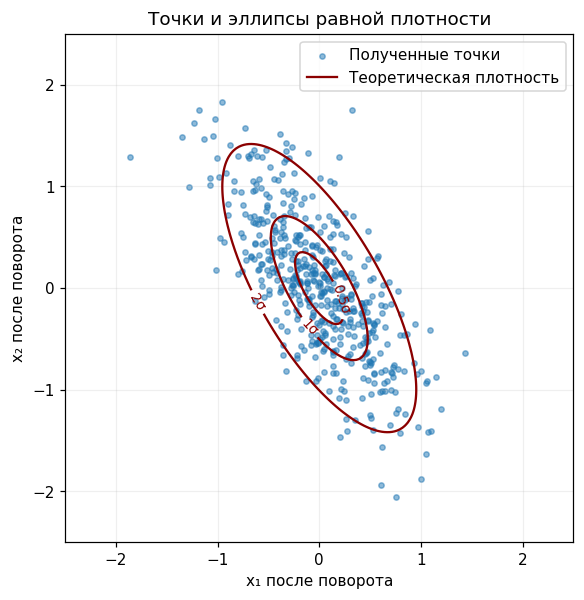

Проверки пункта 1.1 пройдены.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import multivariate_normal
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
np.random.seed(42)

M = 500
sigma1, sigma2 = 0.3, 0.8
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)
alpha = np.deg2rad(30)
R = np.array([[np.cos(alpha), -np.sin(alpha)],
              [np.sin(alpha), np.cos(alpha)]])
X = np.column_stack([x1, x2]) @ R.T
C_theory = R @ np.diag([sigma1**2, sigma2**2]) @ R.T
C_sample = np.cov(X.T)
print('Выборочная ковариация:\n', C_sample)
print('Теоретическая ковариация:\n', C_theory)
print('Разница:\n', C_sample - C_theory)
print('Среднее:', X.mean(axis=0))

gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
points = np.column_stack([gx.ravel(), gy.ravel()])
theory_model = multivariate_normal(mean=[0, 0], cov=C_theory)
density = theory_model.pdf(points).reshape(gx.shape)
# Уровни плотности для расстояний 2, 1 и 0.5 стандартного отклонения.
radii = np.array([2, 1, 0.5])
levels = theory_model.pdf([0, 0]) * np.exp(-radii**2 / 2)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.5, label='Полученные точки')
contours = ax.contour(gx, gy, density, levels=levels, colors='darkred')
ax.clabel(contours, fmt=dict(zip(levels, ['2σ', '1σ', '0.5σ'])), fontsize=9)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [Line2D([0], [0], color='darkred')], labels + ['Теоретическая плотность'])
ax.set(xlabel='x₁ после поворота', ylabel='x₂ после поворота', title='Точки и эллипсы равной плотности')
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.show()

assert X.shape == (M, 2), 'Неверная размерность данных'
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, 'Корреляция слишком мала (проверьте поворот)'
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), 'Среднее должно быть около 0'
print('Проверки пункта 1.1 пройдены.')


### 1.2. Сравнение со встроенной функцией
Я получил второе облако с помощью `np.random.multivariate_normal`, передав ей сразу
среднее и теоретическую ковариацию.


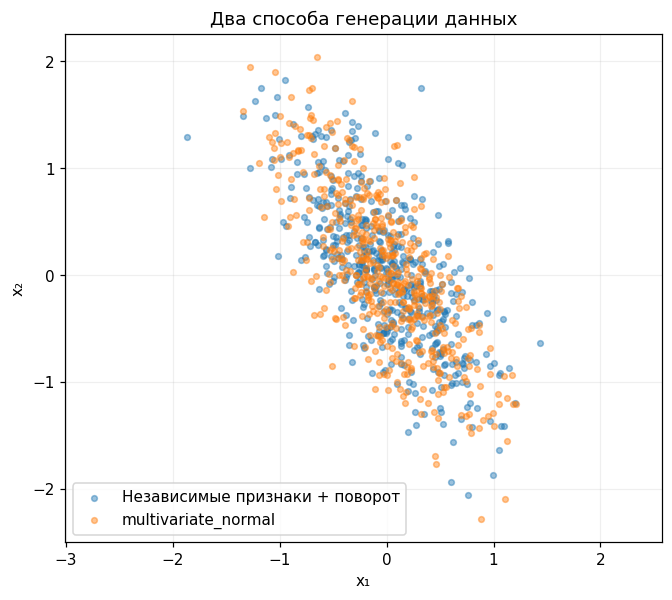

In [2]:
np.random.seed(43)
X_builtin = np.random.multivariate_normal([0, 0], C_theory, M)
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], s=14, alpha=0.45, label='Независимые признаки + поворот')
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], s=14, alpha=0.45, label='multivariate_normal')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Два способа генерации данных')
plt.axis('equal')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


**Совпадают ли облака и почему встроенная функция удобнее?**
Я вижу, что облака похожи по форме и наклону, но сами точки не совпадают, потому что это
разные случайные выборки. Встроенная функция удобнее: я сразу задаю нужную ковариацию
и не рассчитываю поворот отдельно.

**Вывод по части 1.** После поворота между признаками появилась связь.
Выборочная ковариация близка к теоретической, но немного отличается из-за случайности данных.


## Часть 2. Плотность вероятности
Я оценил среднее и ковариацию по точкам из пункта 1.1.
Далее посчитал плотность на сетке от −2 до 2 с помощью SciPy и вручную:

$$p(x)=\frac{1}{(2\pi)^{d/2}\sqrt{\det C}}
\exp\left(-\frac12(x-\mu)^T C^{-1}(x-\mu)\right),\qquad d=2.$$

Большая плотность означает, что в этой области точки встречаются чаще.


Максимальная разница: 3.3306690738754696e-16
Проверка плотности пройдена.


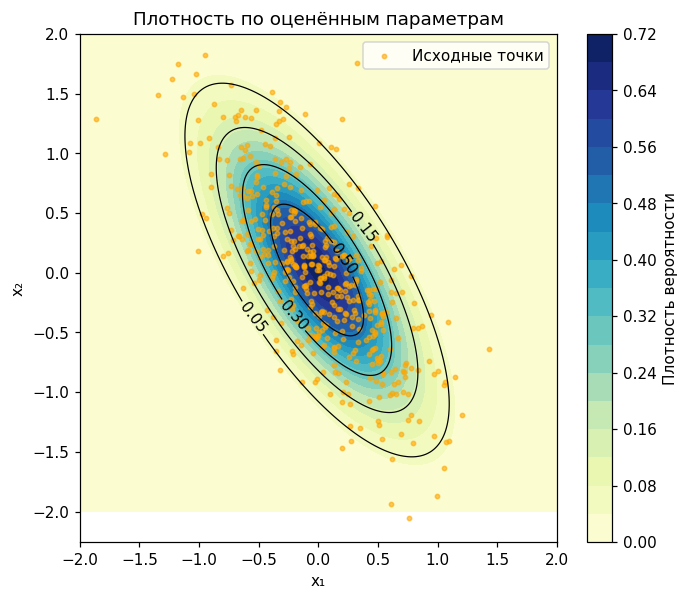

In [3]:
mu = X.mean(axis=0)
C = np.cov(X.T)
xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

diff = grid_points - mu
C_inv = np.linalg.inv(C)
C_det = np.linalg.det(C)
d = X.shape[1]
exponent = -0.5 * np.sum((diff @ C_inv) * diff, axis=1)
pdf_manual = np.exp(exponent) / ((2 * np.pi)**(d / 2) * np.sqrt(C_det))
m = multivariate_normal(mean=mu, cov=C)
pdf_scipy = m.pdf(grid_points)
max_difference = np.max(np.abs(pdf_manual - pdf_scipy))
print('Максимальная разница:', max_difference)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), 'Ручное вычисление отличается от scipy'
assert max_difference < 1e-10
print('Проверка плотности пройдена.')

fig, ax = plt.subplots(figsize=(7, 6))
z = pdf_manual.reshape(xx.shape)
background = ax.contourf(xx, yy, z, levels=20, cmap='YlGnBu')
lines = ax.contour(xx, yy, z, levels=[0.05, 0.15, 0.3, 0.5], colors='black', linewidths=0.8)
ax.clabel(lines, fmt='%.2f')
ax.scatter(X[:, 0], X[:, 1], s=8, color='orange', alpha=0.6, label='Исходные точки')
fig.colorbar(background, ax=ax, label='Плотность вероятности')
ax.set(xlabel='x₁', ylabel='x₂', title='Плотность по оценённым параметрам')
ax.legend()
plt.show()


**Вывод по части 2.** Я получил практически одинаковые значения двумя способами:
разница меньше $10^{-10}$. На графике самая высокая плотность находится около центра облака.


## Часть 3. Бинарная классификация
### 3.1. Генерация двух классов
Я создал два класса по 300 точек со средними и ковариациями из задания.
### 3.2. Граница между классами
Для каждой точки сетки я сравнил две величины:
$$\Delta(x)=p(x\mid0)p(0)-p(x\mid1)p(1).$$
Если разность положительная, выбирается класс 0, если отрицательная — класс 1.
Это разность плотностей с учётом долей классов; сами вероятности классов получаются после
деления на общую сумму. На выбор класса это деление не влияет.


Доли классов: 0.5 0.5


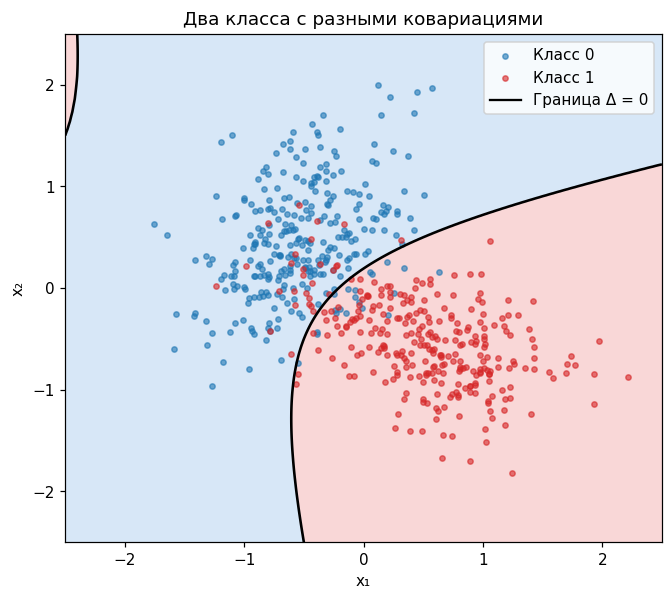

In [4]:
np.random.seed(44)
mu0 = np.array([-0.5, 0.5])
mu1 = np.array([0.5, -0.5])
C0 = np.array([[0.2, 0.1], [0.1, 0.3]])
C1 = np.array([[0.3, -0.1], [-0.1, 0.2]])
X0 = np.random.multivariate_normal(mu0, C0, 300)
X1 = np.random.multivariate_normal(mu1, C1, 300)
X_binary = np.vstack([X0, X1])
y_binary = np.array([0] * 300 + [1] * 300)
prior0 = np.mean(y_binary == 0)
prior1 = np.mean(y_binary == 1)
print('Доли классов:', prior0, prior1)

bx, by = np.meshgrid(np.linspace(-2.5, 2.5, 250), np.linspace(-2.5, 2.5, 250))
binary_grid = np.column_stack([bx.ravel(), by.ravel()])
delta = (multivariate_normal(mu0, C0).pdf(binary_grid) * prior0
         - multivariate_normal(mu1, C1).pdf(binary_grid) * prior1)
delta = delta.reshape(bx.shape)
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(bx, by, delta, levels=[delta.min() - 1, 0, delta.max() + 1],
            colors=['#f7c6c6', '#c7def5'], alpha=0.7)
ax.contour(bx, by, delta, levels=[0], colors='black', linewidths=1.7)
ax.scatter(X0[:, 0], X0[:, 1], s=12, color='tab:blue', alpha=0.6, label='Класс 0')
ax.scatter(X1[:, 0], X1[:, 1], s=12, color='tab:red', alpha=0.6, label='Класс 1')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [Line2D([0], [0], color='black')], labels + ['Граница Δ = 0'])
ax.set(xlabel='x₁', ylabel='x₂', title='Два класса с разными ковариациями')
plt.show()


**Является ли граница линейной?** Нет, здесь она изогнутая. У классов разные матрицы
ковариации, то есть облака имеют разную форму и наклон. Поэтому простая прямая не описывает
эту границу; в её уравнении остаются квадраты признаков.

**Вывод по части 3.** Я построил границу по байесовскому правилу.
Разные ковариации дали нелинейную границу между классами.


## Часть 4. Линейный дискриминантный анализ
### 4.1. Вывод формулы
Теперь у классов одна и та же ковариация $C$. Для сравнения классов я использовал
логарифм отношения их вероятностей:

$$g(x)=\log\frac{p(x\mid1)p(1)}{p(x\mid0)p(0)}.$$

После подстановки нормальной плотности одинаковые множители сокращаются:

$$g(x)=-\frac12(x-\mu_1)^TC^{-1}(x-\mu_1)
+\frac12(x-\mu_0)^TC^{-1}(x-\mu_0)+\log\frac{p(1)}{p(0)}.$$

Я раскрыл скобки. Слагаемые $x^TC^{-1}x$ сократились, и осталось:

$$g(x)=(\mu_1-\mu_0)^TC^{-1}x
-\frac12\mu_1^TC^{-1}\mu_1+\frac12\mu_0^TC^{-1}\mu_0
+\log\frac{p(1)}{p(0)}=w^Tx+b.$$

Значит,
$$w=C^{-1}(\mu_1-\mu_0),\qquad
b=-\frac12\mu_1^TC^{-1}\mu_1+\frac12\mu_0^TC^{-1}\mu_0+\log\frac{p(1)}{p(0)}.$$

При $g(x)>0$ выбирается класс 1. Граница задаётся уравнением $w^Tx+b=0$.
Она линейная, потому что квадратов признаков больше нет.

**Уточнение к заданию:** в указанной там формуле $b$ перепутаны знаки двух слагаемых
со средними. Здесь я использовал знаки, полученные при раскрытии скобок выше.


### 4.2. Реализация MyLDA
Я написал класс для двух классов объектов. Он находит средние, доли классов и общую
ковариацию. Для ковариации я сначала вычитаю среднее своего класса, складываю результаты
и делю на $N-2$. Небольшая добавка к диагонали помогает обратить матрицу.


In [5]:
class MyLDA(ClassifierMixin, BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError('MyLDA рассчитан на два класса')
        self.n_features_in_ = X.shape[1]
        self.means_ = {}
        self.priors_ = {}
        scatter = np.zeros((X.shape[1], X.shape[1]))
        for label in self.classes_:
            part = X[y == label]
            self.means_[label] = part.mean(axis=0)
            self.priors_[label] = len(part) / len(X)
            centered = part - self.means_[label]
            scatter += centered.T @ centered
        self.cov_ = scatter / (len(X) - 2)
        cov_reg = self.cov_ + 1e-6 * np.eye(X.shape[1])
        inv_cov = np.linalg.inv(cov_reg)
        class0, class1 = self.classes_
        mean0, mean1 = self.means_[class0], self.means_[class1]
        self.coef_ = inv_cov @ (mean1 - mean0)
        self.intercept_ = (-0.5 * mean1 @ inv_cov @ mean1
                          + 0.5 * mean0 @ inv_cov @ mean0
                          + np.log(self.priors_[class1] / self.priors_[class0]))
        return self

    def decision_function(self, X):
        return np.asarray(X) @ self.coef_ + self.intercept_

    def predict(self, X):
        return self.classes_[(self.decision_function(X) > 0).astype(int)]

    def predict_proba(self, X):
        # expit переводит результат сравнения в вероятность от 0 до 1.
        prob1 = expit(self.decision_function(X))
        return np.column_stack([1 - prob1, prob1])


### 4.3. Проверка на синтетических данных
Я создал классы с общей ковариацией из задания и разными средними.
Для проверки разделил точки на обучающую и тестовую части: 80% и 20%.

В проверке весов из задания есть неточность: обычное скалярное произведение
сонаправленных векторов не обязано равняться 1. Поэтому я разделил его на длины векторов
и взял строку `sk_lda.coef_[0]`, чтобы размеры совпадали.


Совпадение предсказаний: 1.0
Доля правильных ответов MyLDA: 0.9
Веса: [2.0241 0.6899] Свободный член: -1.0009
Проверки LDA пройдены.


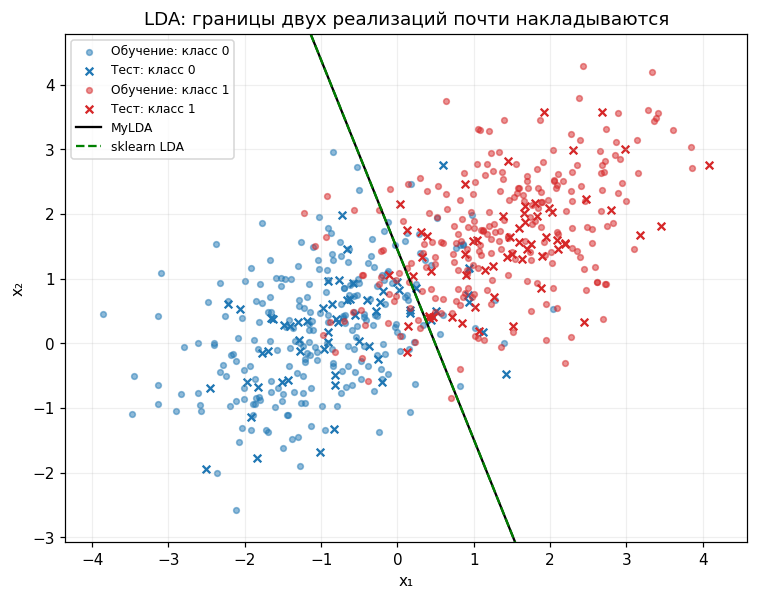

In [6]:
np.random.seed(45)
C_equal = np.array([[1, 0.5], [0.5, 1]])
X_lda0 = np.random.multivariate_normal([-1, 0.2], C_equal, 300)
X_lda1 = np.random.multivariate_normal([1.4, 1.8], C_equal, 300)
X_lda = np.vstack([X_lda0, X_lda1])
y_lda = np.array([0] * 300 + [1] * 300)
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y_lda, test_size=0.2, random_state=42, stratify=y_lda)
my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), 'Предсказания не совпадают'
w_my, w_sk = my_lda.coef_, sk_lda.coef_[0]
cos_angle = (w_my @ w_sk) / (np.linalg.norm(w_my) * np.linalg.norm(w_sk))
assert abs(cos_angle - 1) < 1e-6, 'Направления весов различаются'
probabilities = my_lda.predict_proba(X_test)
assert probabilities.shape == (len(X_test), 2)
assert np.allclose(probabilities.sum(axis=1), 1)
assert np.allclose(probabilities, sk_lda.predict_proba(X_test), atol=1e-5)
print('Совпадение предсказаний:', np.mean(my_lda.predict(X_test) == sk_lda.predict(X_test)))
print('Доля правильных ответов MyLDA:', np.mean(my_lda.predict(X_test) == y_test))
print('Веса:', my_lda.coef_, 'Свободный член:', round(my_lda.intercept_, 4))
print('Проверки LDA пройдены.')

lx, ly = np.meshgrid(np.linspace(X_lda[:, 0].min() - 0.5, X_lda[:, 0].max() + 0.5, 200),
                     np.linspace(X_lda[:, 1].min() - 0.5, X_lda[:, 1].max() + 0.5, 200))
lda_grid = np.column_stack([lx.ravel(), ly.ravel()])
fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [(0, 'tab:blue'), (1, 'tab:red')]:
    train = X_train[y_train == label]
    test = X_test[y_test == label]
    ax.scatter(train[:, 0], train[:, 1], c=color, s=14, alpha=0.5, label=f'Обучение: класс {label}')
    ax.scatter(test[:, 0], test[:, 1], c=color, marker='x', s=25, label=f'Тест: класс {label}')
ax.contour(lx, ly, my_lda.decision_function(lda_grid).reshape(lx.shape), levels=[0], colors='black')
ax.contour(lx, ly, sk_lda.decision_function(lda_grid).reshape(lx.shape), levels=[0], colors='green', linestyles='--')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [Line2D([0], [0], color='black'), Line2D([0], [0], color='green', linestyle='--')],
          labels + ['MyLDA', 'sklearn LDA'], fontsize=8)
ax.set(xlabel='x₁', ylabel='x₂', title='LDA: границы двух реализаций почти накладываются')
ax.grid(alpha=0.2)
plt.show()


**Вывод по части 4.** Я получил прямую границу, как и ожидалось при общей ковариации.
Мой LDA и модель из sklearn дали одинаковые классы для всех тестовых объектов;
это означает совпадение моделей на этой проверке, а не отсутствие ошибок относительно настоящих меток.


## Часть 5. Наивный байесовский классификатор
### 5.1. Почему ковариация диагональная?
В наивном байесе я считаю признаки независимыми внутри каждого класса.
Поэтому модель не учитывает их взаимную связь, и вне диагонали стоят нули.
На диагонали остаются только дисперсии — разброс каждого признака.
Тогда плотность можно считать для каждого признака отдельно и перемножать результаты.
Это проще, чем работать с полной матрицей ковариации.

### 5.2. Реализация MyNB
Я использовал логарифмы: так вместо перемножения очень маленьких чисел получается сумма.
К дисперсиям добавил небольшое число, как в GaussianNB, чтобы избежать деления на ноль.


In [7]:
class MyNB(ClassifierMixin, BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}
        epsilon = max(1e-9 * np.var(X, axis=0).max(), 1e-12)
        for label in self.classes_:
            part = X[y == label]
            self.means_[label] = part.mean(axis=0)
            self.vars_[label] = part.var(axis=0) + epsilon
            self.priors_[label] = len(part) / len(X)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        scores = []
        for label in self.classes_:
            mean = self.means_[label]
            var = self.vars_[label]
            log_prob = np.log(self.priors_[label]) - 0.5 * np.sum(
                np.log(2 * np.pi * var) + (X - mean)**2 / var, axis=1)
            scores.append(log_prob)
        return self.classes_[np.argmax(np.column_stack(scores), axis=1)]


### 5.3. Сравнение со sklearn
Для проверки я использовал ту же обучающую и тестовую выборки, что и в части 4.


In [8]:
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), 'Предсказания NB не совпадают'
print('Совпадение предсказаний:', np.mean(my_nb.predict(X_test) == sk_nb.predict(X_test)))
print('Доля правильных ответов MyNB:', np.mean(my_nb.predict(X_test) == y_test))
print('Проверка NB пройдена.')


Совпадение предсказаний: 1.0
Доля правильных ответов MyNB: 0.8833333333333333
Проверка NB пройдена.


**Вывод по части 5.** Я написал наивный байесовский классификатор через средние и дисперсии
признаков. На тестовой выборке его предсказания совпали с GaussianNB из sklearn.


## Часть 6. Датасет А
### 6.1. Генерация данных с общей ковариацией
Я подготовил только датасет А: у двух классов разные средние, но одна ковариация.
Сначала использовал `make_classification` с 10 признаками, из которых 5 информативных и 2 избыточных.

Сама эта функция не гарантирует одинаковую ковариацию классов.
Поэтому я взял из полученных данных средние и рассчитал одну общую ковариацию.
Затем с этими параметрами создал два нормальных облака по 300 точек.
Условия «5 информативных и 2 избыточных» задаются исходному генератору;
окончательный датасет А получается дополнительной генерацией с общей ковариацией.


Размер датасета А: (600, 10)
Количество объектов в классах: [300 300]
Оба класса созданы с одной матрицей ковариации размера (10, 10)


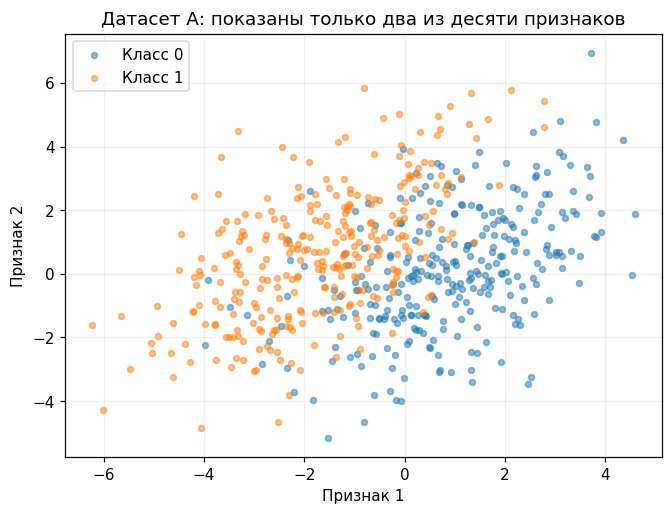

In [9]:
X_base, y_base = make_classification(
    n_samples=600, n_features=10, n_informative=5, n_redundant=2,
    n_clusters_per_class=1, flip_y=0, random_state=46)
mean_A0 = X_base[y_base == 0].mean(axis=0)
mean_A1 = X_base[y_base == 1].mean(axis=0)
centered = np.vstack([X_base[y_base == 0] - mean_A0,
                      X_base[y_base == 1] - mean_A1])
C_A = np.cov(centered.T) + 1e-6 * np.eye(10)
np.random.seed(47)
X_A0 = np.random.multivariate_normal(mean_A0, C_A, 300)
X_A1 = np.random.multivariate_normal(mean_A1, C_A, 300)
X_A = np.vstack([X_A0, X_A1])
y_A = np.array([0] * 300 + [1] * 300)
assert X_A.shape == (600, 10)
assert y_A.shape == (600,)
assert not np.allclose(mean_A0, mean_A1)
print('Размер датасета А:', X_A.shape)
print('Количество объектов в классах:', np.bincount(y_A))
print('Оба класса созданы с одной матрицей ковариации размера', C_A.shape)

plt.figure(figsize=(7, 5))
plt.scatter(X_A0[:, 0], X_A0[:, 1], s=15, alpha=0.5, label='Класс 0')
plt.scatter(X_A1[:, 0], X_A1[:, 1], s=15, alpha=0.5, label='Класс 1')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Датасет А: показаны только два из десяти признаков')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


**Вывод по части 6.1.** Я создал 600 объектов с 10 признаками и общей заданной ковариацией
двух классов. Ковариации, посчитанные по отдельным случайным выборкам, могут немного отличаться.


## Вывод
В ходе выполнения данной работы я познакомился и изучил LDA и наивный байесовский классификатор, а также написал их простые реализации и сравнить результаты с готовыми моделями. Также я посмотрел, как связь между признаками и разброс данных влияют на границу между классами. Я понял, что сначала модель описывает данные каждого класса, а затем выбирает наиболее подходящий класс. Далее я вычислил плотность вручную и через SciPy, и результаты совпали с очень маленькой погрешностью. На примере двух классов я увидел, что разные ковариации могут давать изогнутую границу. Я использовал это свойство при написании MyLDA, который рассматривает признаки как независимые внутри каждого класса. Так ему достаточно отдельных дисперсий, и не нужно учитывать все связи между признаками. Для вычислений я использовал логарифмы, чтобы не перемножать слишком маленькие числа. Предсказания MyNB также совпали с готовой моделью GaussianNB на выбранной тестовой выборке. В конце я создал датасет А с 10 признаками и одинаковой заданной ковариацией классов. Я сделал вывод, что при выборе модели важно учитывать её предположения о данных. В выполненных проверках обе реализации сработали правильно, но это не означает, что одна из них будет лучше на любом наборе данных.
